In [7]:
import numpy as np
import matplotlib.pyplot as plt

Question 2.6

The value of Lambda for a lagrange polynomial at m = 10 is given by 29.89069531652602


/Users/oscarlewis/Desktop/python/physical_systems/Non-Quantum/numerical_methods_assignment_2/lebesgue_constants_a2.py:25: RuntimeWarning: divide by zero encountered in divide
  return 2**x / x


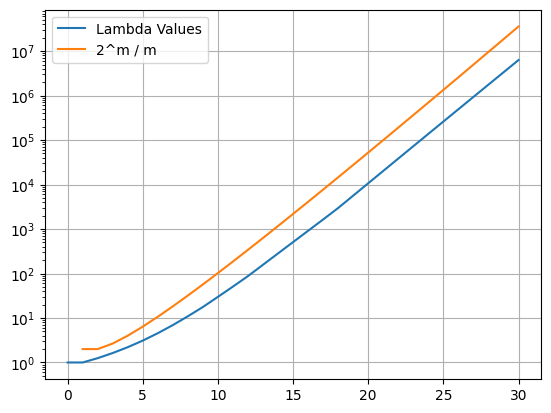

In [8]:
#Defining L_k(x) to use in the definition of Lambda.

from lebesgue_constants_a2 import Lambda

print('The value of Lambda for a lagrange polynomial at m = 10 is given by', Lambda(10))

from lebesgue_constants_a2 import f 

m_values = np.arange(31)
plot_values = [Lambda(m) for m in m_values]
y_values = f(m_values)
plt.plot(m_values, plot_values, label='Lambda Values')
plt.plot(m_values, y_values, label='2^m / m')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()
    

We see that Lambda behaves like 2^m / m on a log graph, hence by reversing this we gain that Lambda(m) behaves like 2^m / m * log(m) on a regular plot. Since Lambda(m) is quickly increasing, we conclude that it is becoming more unstable (Lambda(m) goes to infinity as m \to infinity). This is because we are likely to experience the Runge phenomenom at the end points of our lagrange polynomials, which increases the Lebesque constant. This large constant implies that small deviations in f can cause large differences in the interpolating polynomials. If this numerical method was to converge, then p_m would uniformly converge to f, which is clearly impossible because of the Runge phenomenom.

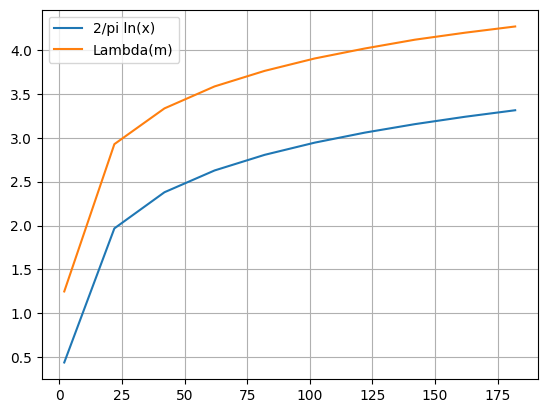

In [9]:
from lebesgue_constants_a2 import LambdaC, g

m2_values = np.arange(2, 202, 20)
plot2_values = [LambdaC(m) for m in m2_values]
y2_values = g(m2_values)
plt.plot(m2_values, y2_values, label='2/pi ln(x)')
plt.plot(m2_values, plot2_values, label='Lambda(m)')
plt.legend()
plt.grid(True)
plt.show()


The two plots are closest at small m, and gradually get further apart as m increases. This is different to our other plot, as the distance between them remains relatively constant for any value of m. This means it is not as good of an approximation compared with the approximation of the Lebesque constant above.

Question 2.7

-0.010393219665581396


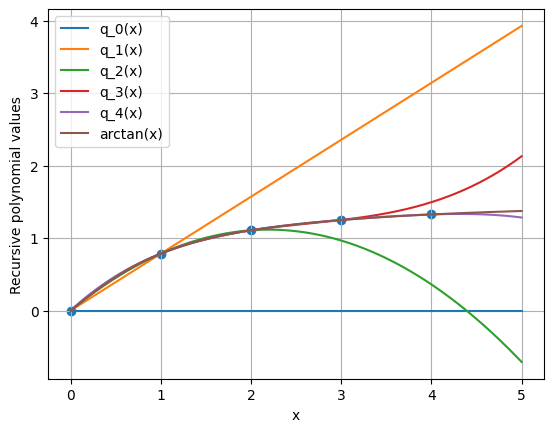

In [10]:
from newton_interpolation_a2 import recursive_f, h
print(recursive_f(h, [0, 1, 2, 3]))

from newton_interpolation_a2 import qk, j
x_vals = np.linspace(0, 5, 501)

nodes = [0, 1, 2, 3, 4]

function_vals = j(x_vals)
for k in range(5): #Plotting q_k for each k
    plt.plot(x_vals, [qk(j, nodes, k, x) for x in x_vals], label=f'q_{k}(x)')

plt.plot(x_vals, function_vals, label='arctan(x)')
plt.scatter(nodes, j(nodes)) #plotting nodes
plt.legend()
plt.grid(True)
plt.xlabel('x')
plt.ylabel('Recursive polynomial values')
plt.show()



In [11]:
#Defining each approximation using the formulas in the notes
from quadrature_rules_a2 import midpoint, trapezoidal, simpson, r
#Using the functions to get the approximations

mid_value = midpoint(r, -1, 1)
trap_value = trapezoidal(r, -1, 1)
simp_value = simpson(r, -1, 1)
real_value = (np.exp(2) - np.exp(-2)) / 2 #By integrating

mid_error = abs(mid_value - real_value)
trap_error = abs(trap_value - real_value)
simp_error = abs(simp_value - real_value)

import pandas as pd #importing pandas library to use as taught in MA124

#Defining the data for our table
data = {
    "Method":["Midpoint", "Trapezoidal", "Simpson"],
    "Value": [mid_value, trap_value, simp_value],
    "Error": [mid_error, trap_error, simp_error]
}
table = pd.DataFrame(data) #Using a pandas function to create the table

table["Value"] = table["Value"].round(3) #Rounding the 'value' column (not asked to do but to make table look cleaner)
table["Error"] = table["Error"].round(3) #Rounding the 'error' column

print(table)


        Method  Value  Error
0     Midpoint  2.000  1.627
1  Trapezoidal  7.524  3.898
2      Simpson  3.841  0.215


We see that the Simpson formula provides the best approximation to our integral by a big distance, but it is surprising to see here that the midpoint formula provided a better approximation than the trapezoidal formula. The trapezoidal formula provides such a poor approximation due to f(b) being significantly higher than the rest of the function, and hence inflating the estimate.

The values for midpoint approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by [0.6666666666666666, 0.4, 0.2222222222222222, 0.11764705882352941, 0.06060606060606061, 0.03076923076923077, 0.015503875968992248, 0.007782101167315175, 0.003898635477582846, 0.001951219512195122, 0.0009760858955588092]
The values for trapezoidal approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by [0.75, 0.41666666666666663, 0.225, 0.11805555555555555, 0.06066176470588235, 0.030776515151515152, 0.015504807692307693, 0.007782218992248062, 0.003898650291828794, 0.0019512213693957114, 0.0009760861280487805]
The values for simpson approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by [0.6944444444444443, 0.40555555555555556, 0.22314814814814812, 0.11778322440087144, 0.06062462863933452, 0.030771658896658897, 0.015504186543430729, 0.007782140442292804, 0.003898640415664828, 0.001951220131261985, 0.0009760859730554663]
The real values of the integr

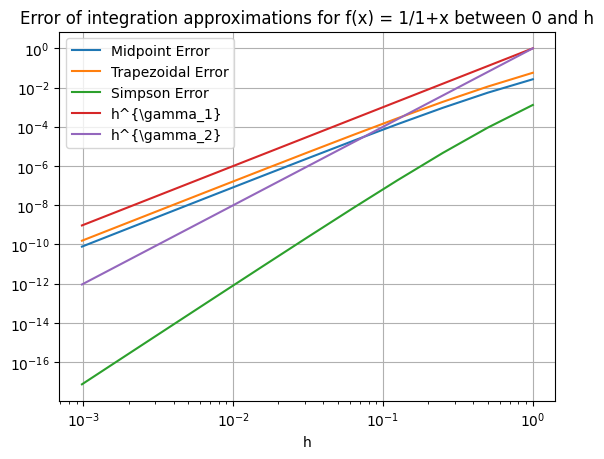

In [15]:
h_values = [2**-k for k in range(11)]
from quadrature_rules_a2 import p, exact_value

#Collecting the values of the integral approximation and the error for each method
mid_values = [midpoint(p, 0, h) for h in h_values]
mid_errors = [abs(midpoint(p, 0, h) - exact_value(h)) for h in h_values]

trap_values = [trapezoidal(p, 0, h) for h in h_values]
trap_errors = [abs(trapezoidal(p, 0, h) - exact_value(h)) for h in h_values]

simp_values = [simpson(p, 0, h) for h in h_values]
simp_errors = [abs(simpson(p, 0, h) - exact_value(h)) for h in h_values]

exact_values = [exact_value(h) for h in h_values]

print('The values for midpoint approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by', mid_values)
print('The values for trapezoidal approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by', trap_values)
print('The values for simpson approximation of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by', simp_values)
print('The real values of the integral of f(x) = 1/1 + x on [0,h] for h = 2^0,...,2^-10 are given by', exact_values)

#We now plot the log-log graphs
gamma1 = 3
gamma1_values = [h**gamma1 for h in h_values]

gamma2 = 4
gamma2_values = [h**gamma2 for h in h_values]

plt.loglog(h_values, mid_errors, label='Midpoint Error')
plt.loglog(h_values, trap_errors, label='Trapezoidal Error')
plt.loglog(h_values, simp_errors, label='Simpson Error')
plt.loglog(h_values, gamma1_values, label=r'h^{\gamma_1}')
plt.loglog(h_values, gamma2_values, label=r'h^{\gamma_2}')
plt.xlabel('h')
plt.title('Error of integration approximations for f(x) = 1/1+x between 0 and h')
plt.legend()
plt.grid(True)
plt.show()

We see that the h^{gamma_1} (with gamma_1 = 3) has approximately the same gradient/ scaling as both the Midpoint and Trapezoidal error, and h^{gamma_2} (with gamma_2 = 4) has approximately the same gradient / scaling as the Simpson error. This tells us that the error of each method is approximate to an integer power of h. We also see that the error is very nearly linear as expected by the formulas derived in the notes.

In [13]:
#We use the formula in the notes to create an array of EOC values for each method
mid_eoc = [None] + [1/np.log(2) * np.log(mid_errors[i - 1] / mid_errors[i]) for i in range(1, 11)] 
trap_eoc = [None] + [1/np.log(2) * np.log(trap_errors[i - 1] / trap_errors[i]) for i in range(1, 11)]
simp_eoc = [None] + [1/np.log(2) * np.log(simp_errors[i - 1] / simp_errors[i]) for i in range(1, 11)]

#Creating the data for the table, and creating the table in the exact same way as done for a).
data1 = {
    "h": h_values,
    "Midpoint EOC": mid_eoc,
    "Trapezoidal EOC": trap_eoc,
    "Simpson EOC": simp_eoc
}
table1 = pd.DataFrame(data1)
table1["Midpoint EOC"] = table1["Midpoint EOC"].round(3)
table1["Trapezoidal EOC"] = table1["Trapezoidal EOC"].round(3)
table1["Simpson EOC"] = table1["Simpson EOC"].round(3)
print(table1)


           h  Midpoint EOC  Trapezoidal EOC  Simpson EOC
0   1.000000           NaN              NaN          NaN
1   0.500000         2.277            2.344        3.842
2   0.250000         2.568            2.593        4.298
3   0.125000         2.760            2.768        4.606
4   0.062500         2.873            2.875        4.790
5   0.031250         2.935            2.935        4.891
6   0.015625         2.967            2.967        4.945
7   0.007812         2.983            2.983        4.972
8   0.003906         2.992            2.992        4.986
9   0.001953         2.996            2.996        4.993
10  0.000977         2.998            2.998        4.999
